In [7]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec

from fiat_toolbox.well_being import CommunityUnit, WellBeingConfig, CapitalStock, IncomeConfig, SimulationConfig, Liquidity, LossType

In [8]:
housing_assets = CapitalStock(v=0.7, k=80000)
rental_assets = CapitalStock(v=0.7, k=30000, recovery_time=10)

public_assets = CapitalStock(v=0.4, k=1e-2*5000000, recovery_time=10)
private_assets = CapitalStock(v=0.4, k=1e-2*5000000, recovery_time=4)

income_config = IncomeConfig(i_0=48000, i_avg=48000, pi=0.15, i_div=10000)
sim_config = SimulationConfig(eta=1.5, rho=0.06, t_max=10, dt=1/52, currency="$", c_min=0.0, recovery_per=95.0)
liq = Liquidity(savings=10000)

config = WellBeingConfig(
    owner_housing=housing_assets,
    labour_assets={"Public":public_assets, "Private":private_assets},
    rental_housing=rental_assets,
    income=income_config,
    simulation=sim_config,
    liquidity=liq
    
)

In [9]:
# Create a WellBeing object and optimize the lambda value
household = CommunityUnit(config=config)
household

CommunityUnit(
  owner_housing = k=80000.0 v=0.7 recovery_time=None recovery_rate=None,
  rental_housing = k=30000.0 v=0.7 recovery_time=10.0 recovery_rate=0.299573227355399,
  labour_assets = {'Public': CapitalStock(k=50000.0, v=0.4, recovery_time=10.0, recovery_rate=0.299573227355399), 'Private': CapitalStock(k=50000.0, v=0.4, recovery_time=4.0, recovery_rate=0.7489330683884975)},
  income = i_0=48000.0 i_avg=48000.0 pi=0.15 i_div=10000.0,
  liquidity = savings=10000.0 insurance=0.0 support=0.0,
  simulation = eta=1.5 rho=0.06 t_max=10.0 dt=0.019230769230769232 currency='$' c_min=0.0 recovery_per=95.0
)

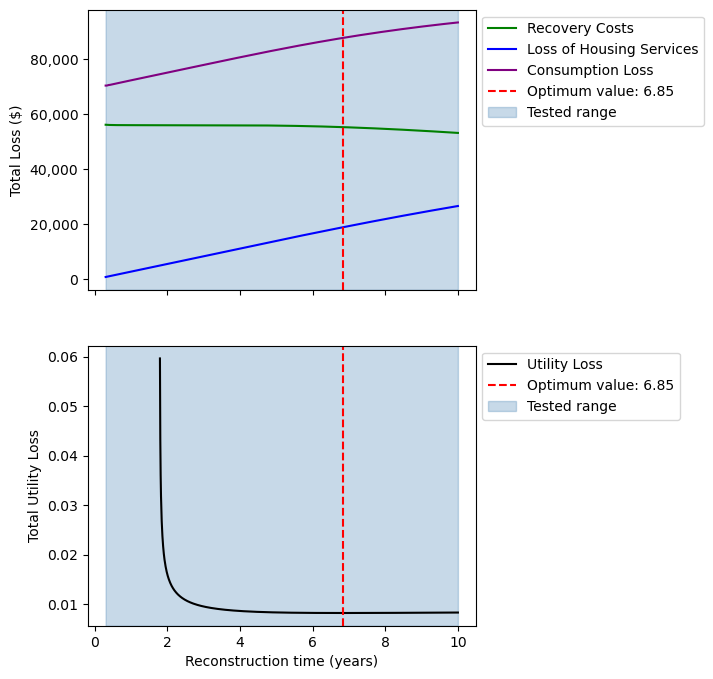

In [10]:
household.opt_lambda(method="trapezoid", eps_rel=0.)
household.plot_opt_lambda(x_type="time");

In [11]:
household.get_losses("trapezoid")

Recovery Costs                       55294.437930
Loss of Housing Services             18963.935637
Loss of Housing Services (Rental)     9989.237928
Labour Income Loss (Public)           9513.559931
Labour Income Loss (Private)          4003.528094
Labour Income Loss                   13517.088025
Consumption Loss                     87764.072565
Utility Loss                             0.008231
Wellbeing Loss                       76299.320289
Asset Loss                           56000.000000
Equity Weighted Loss                 42160.707748
dtype: float64

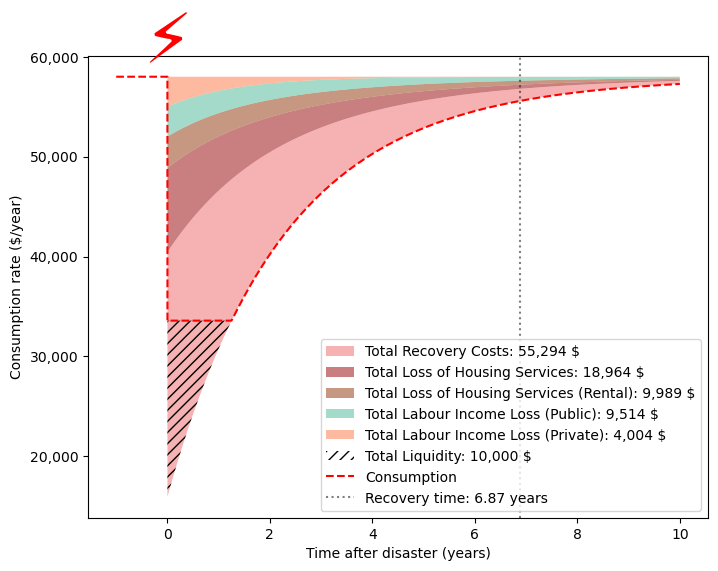

In [12]:
household.plot_consumption()